# Spike Detection
We will implement three spike detection methods:
*   Hard threshold
*   Differential threshold
*   Precision timing spike detection (PTSD)

### Author
- Simone Migliazza

In [30]:
# from google.colab import drive
# drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from scipy.io import loadmat
from scipy.stats import median_abs_deviation
from scipy.signal import find_peaks, argrelextrema

def plot_method(path):
  img = mpimg.imread(path)
  plt.imshow(img)
  plt.axis('off')
  plt.show()

## Load and plot the data

In [31]:
mat_file = loadmat('./data/data.mat')

# Extract data
data = mat_file['data'].squeeze()
sampling_interval = mat_file['samplingInterval'][0][0]
sfreq = 1 / (sampling_interval * 1e-3) # sampling frequency

## Define the parameters

In [32]:
RP = 1e-3 # refractory period (1 ms)

## Hard threshold
We implement a function `hard_threshold_SD()` to detect spikes, looking for the local maxima within the raw signal.
If a local maximum is higher than the threshold, we have a spike!

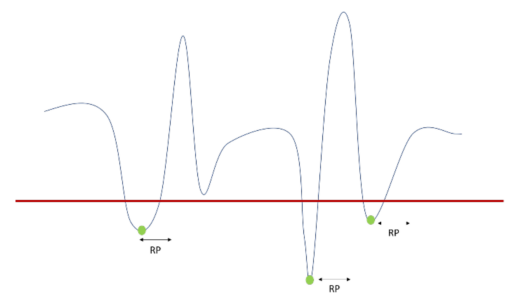

In [33]:
plot_method("./images/FigHT.png")

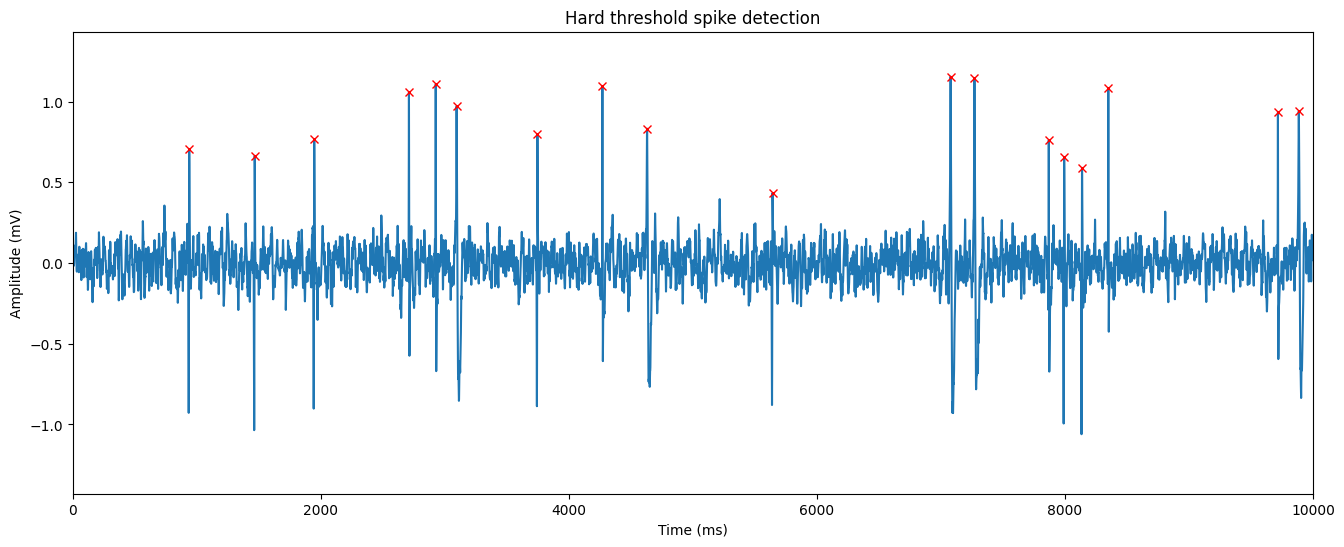

In [34]:
def hard_th(data, th, RP, sfreq):
    """
    Hard threshold spike detection function.

    Detects spikes in a signal using a simple hard threshold.
    A spike is detected if the signal amplitude exceeds the threshold.

    Parameters
    ----------
    data : array-like
        The input signal.
    th : float
        The threshold value.
    RP : float
        The refractory period in seconds.
    sfreq : float
        The sampling frequency in Hz.

    Returns
    -------
    spike_train : array-like
        The indices of the detected spikes in the input signal.
    """

    spike_train, _ = find_peaks(data, height=th)

    return spike_train


# Hard threshold spike detection
th = 4 * 1.4826 * median_abs_deviation(data) # T_hr = 4 * 1.4826 · MAD
spike_train_ht = hard_th(data, th, RP, sfreq)

# Plot spikes
plt.figure(figsize=(16, 6))
plt.plot(data)
plt.plot(spike_train_ht, data[spike_train_ht], 'rx')
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude (mV)')
plt.title('Hard threshold spike detection')
plt.xlim([0, 10000]) # plotting only the first TEN seconds to make spikes more visible
plt.show()

## Differential threshold
We implement a function `differential_threshold_SD()` to detect spikes.
First, we compute the difference between maximum and minimum values within a window. If the difference is higher than the threshold, we have a spike!


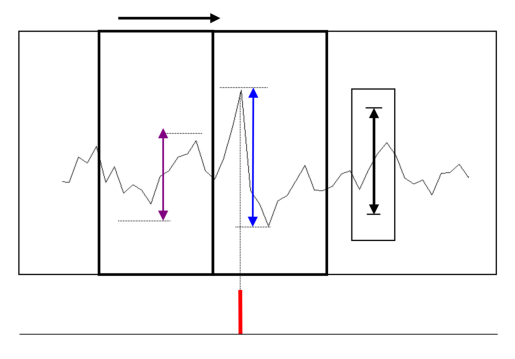

In [35]:
plot_method("./images/FigDT.png")

55


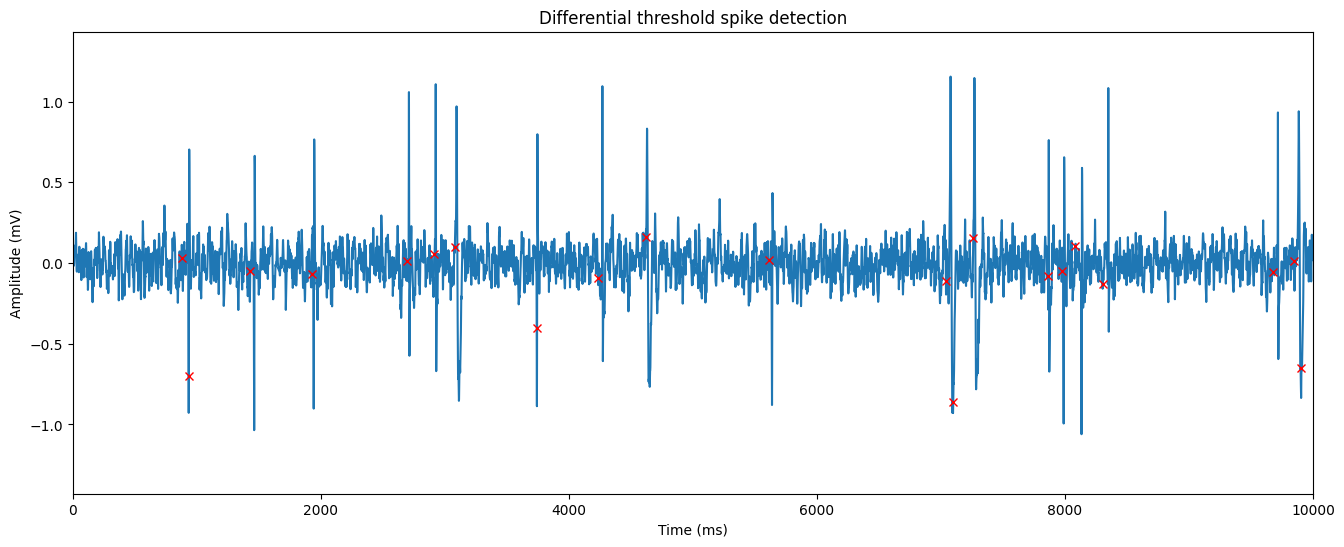

In [36]:
def differential_th(data, th, wdw_length, sfreq):
    """
    Differential threshold spike detection function.

    Detects spikes in a signal using a differential threshold.
    A spike is detected if the difference between the maximum and
    minimum values within a window exceeds the threshold.

    Parameters
    ----------
    data : array-like
        The input signal.
    th : float
        The threshold value.
    wdw_length : float
        The window length in seconds.
    sfreq : float
        The sampling frequency in Hz.

    Returns
    -------
    spike_train : array-like
        The indices of the detected spikes in the input signal.
    """

    spike_train = []
    displacement = int(wdw_length * sfreq)
    print(displacement)
    i = 0
    while i < len(data):
      wdw = data[i:i+displacement]
      if np.max(wdw) - np.min(wdw) > th:
        spike_train.append(i)
      i += displacement
    return spike_train

# Differential threshold spike detection
th = 6 * np.std(data)
wdw_length = 2.3 * 1e-3
spike_train_dt = differential_th(data, th, wdw_length, sfreq)

# Plot spikes
plt.figure(figsize=(16, 6))
plt.plot(data)
plt.plot(spike_train_dt, data[spike_train_dt], 'rx')
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude (mV)')
plt.title('Differential threshold spike detection')
plt.xlim([0, 10000]) # plotting only the first TEN seconds to make spikes more visible
plt.show()

## Precision Timing Spike Detection (PTSD)


*   Identify local maxima in the raw signal.
*   For each local maximum, search for a local minimum within the Peak Lifetime Period (PLP). If no minimum is found, extend the search by adding an overshoot to PLP.
*   If a local minimum is found: check if the amplitude difference (max - min) exceeds the threshold (th). Ensure the detected spike is at least Refractory Period (RP) away from the following spike.
*   If all the conditions are met, we have a spike!

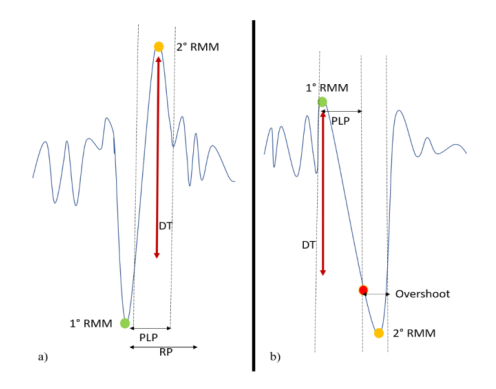

In [37]:
plot_method("./images/FigPTSD.png")

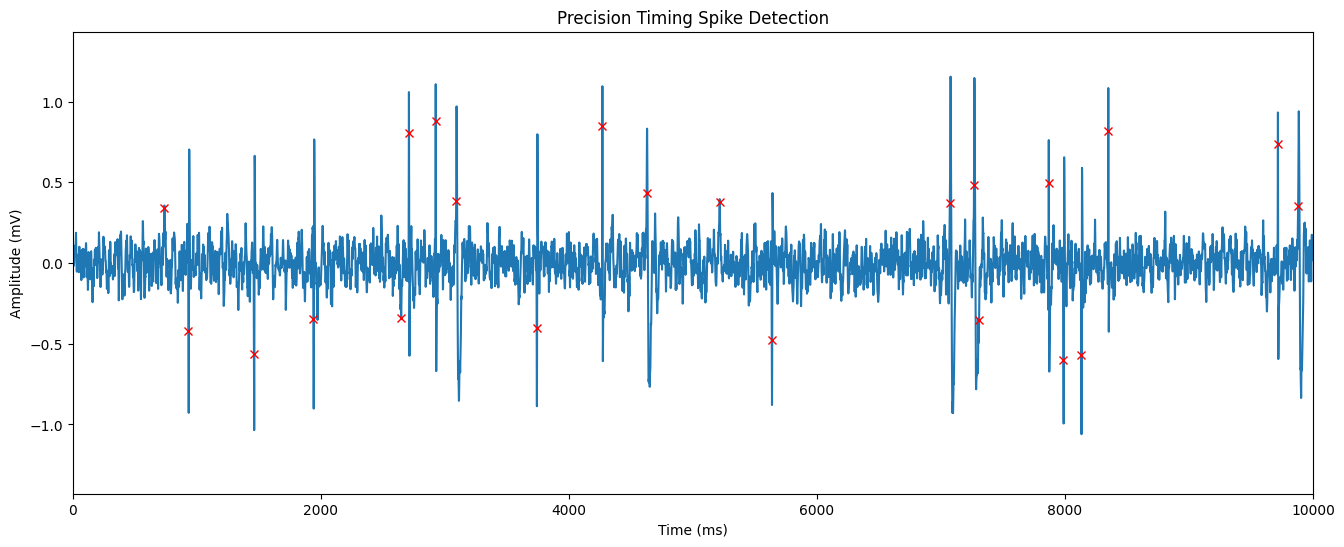

In [38]:
def PTSD(data, th, PLP, overshoot, RP, sfreq):
    """
    Precision Timing Spike Detection (PTSD) function.

    This method solves the undersampling issue. The operation of PTSD differs from previous algorithms in several aspects:
    - It uses a differential threshold instead of a unipolar one.
    - In addition to the refractory period (RP), there is another time interval called Peak Lifetime Period (PLP), 
        which is the maximum duration that a spike can have.

    Parameters
    ----------
    data : array-like
        The input signal.
    th : float
        The threshold value.
    PLP : float
        The peak lifetime period in seconds.
    overshoot : float
        The overshoot value in seconds.
    RP : float
        The refractory period in seconds.
    sfreq : float
        The sampling frequency in Hz.

    Returns
    -------
    spike_train : array-like
        The indices of the detected spikes in the input signal.
    """

    spike_train = []
    PLP_samples = int(PLP * sfreq)
    RP_samples = int(RP * sfreq)
    overshoot_samples = int(overshoot * sfreq)
    
    i = 0
    while i < len(data):
        # Find 1st RMM
        if data[i] > th:
            first_RMM_idx = i
            search_start = i
            search_end = min(i + PLP_samples, len(data))
            
            # Find 2nd RMM (nearest minimum within PLP)
            second_RMM_idx = search_start + np.argmin(data[search_start:search_end])
            
        elif data[i] < -th:
            first_RMM_idx = i
            search_start = i
            search_end = min(i + PLP_samples, len(data))
            
            # Find 2nd RMM (nearest maximum within PLP)
            second_RMM_idx = search_start + np.argmax(data[search_start:search_end])
        else:
            i += 1
            continue
            
        # Overshoot check
        if second_RMM_idx == search_end -1 and second_RMM_idx < len(data) -1:
            overshoot_start = second_RMM_idx
            overshoot_end = min(second_RMM_idx + overshoot_samples, len(data))
            
            if data[i] > th:
                 second_RMM_idx = overshoot_start + np.argmin(data[overshoot_start:overshoot_end])
            elif data[i] < -th:
                second_RMM_idx = overshoot_start + np.argmax(data[overshoot_start:overshoot_end])
        
        #Differential Threshold check
        if abs(data[first_RMM_idx] - data[second_RMM_idx]) > th:
            spike_train.append(first_RMM_idx)
            i = second_RMM_idx + RP_samples # Move index to account for Refractory Period
        else:
            i += 1

    return spike_train

# Precision timing spike detection (PTSD)
PLP = 1 * 1e-3
th = 2 * np.std(data)
overshoot = 0.5 * 1e-3
spike_train_ptsd = PTSD(data, th, PLP, overshoot, RP, sfreq)

# Plot spikes
plt.figure(figsize=(16, 6))
plt.plot(data)
plt.plot(spike_train_ptsd, data[spike_train_ptsd], 'rx')
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude (mV)')
plt.title('Precision Timing Spike Detection')
plt.xlim([0, 10000]) # plotting only the first TEN seconds to make spikes more visible
plt.show()